# Regression Assignment - Task 1

In this assignment, we will use the California housing dataset to build a regression model. We will explore data preprocessing, perform Exploratory Data Analysis (EDA) with visualizations, handle missing values, apply different models, and perform hyperparameter tuning.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
import warnings

warnings.filterwarnings('ignore')

## 2. Load the Dataset

In [2]:
df = pd.read_csv('housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 3. Exploratory Data Analysis (EDA)
Before building our models, it is essential to understand the distribution of our data and the relationships between features.

### Basic Information and Missing Values

In [3]:
df.info()
print("\n--- Missing Values ---")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB

--- Missing Values ---
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_pr

### Summary Statistics

In [4]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### Feature Distributions
Let's look at the distribution of the numerical features using histograms.

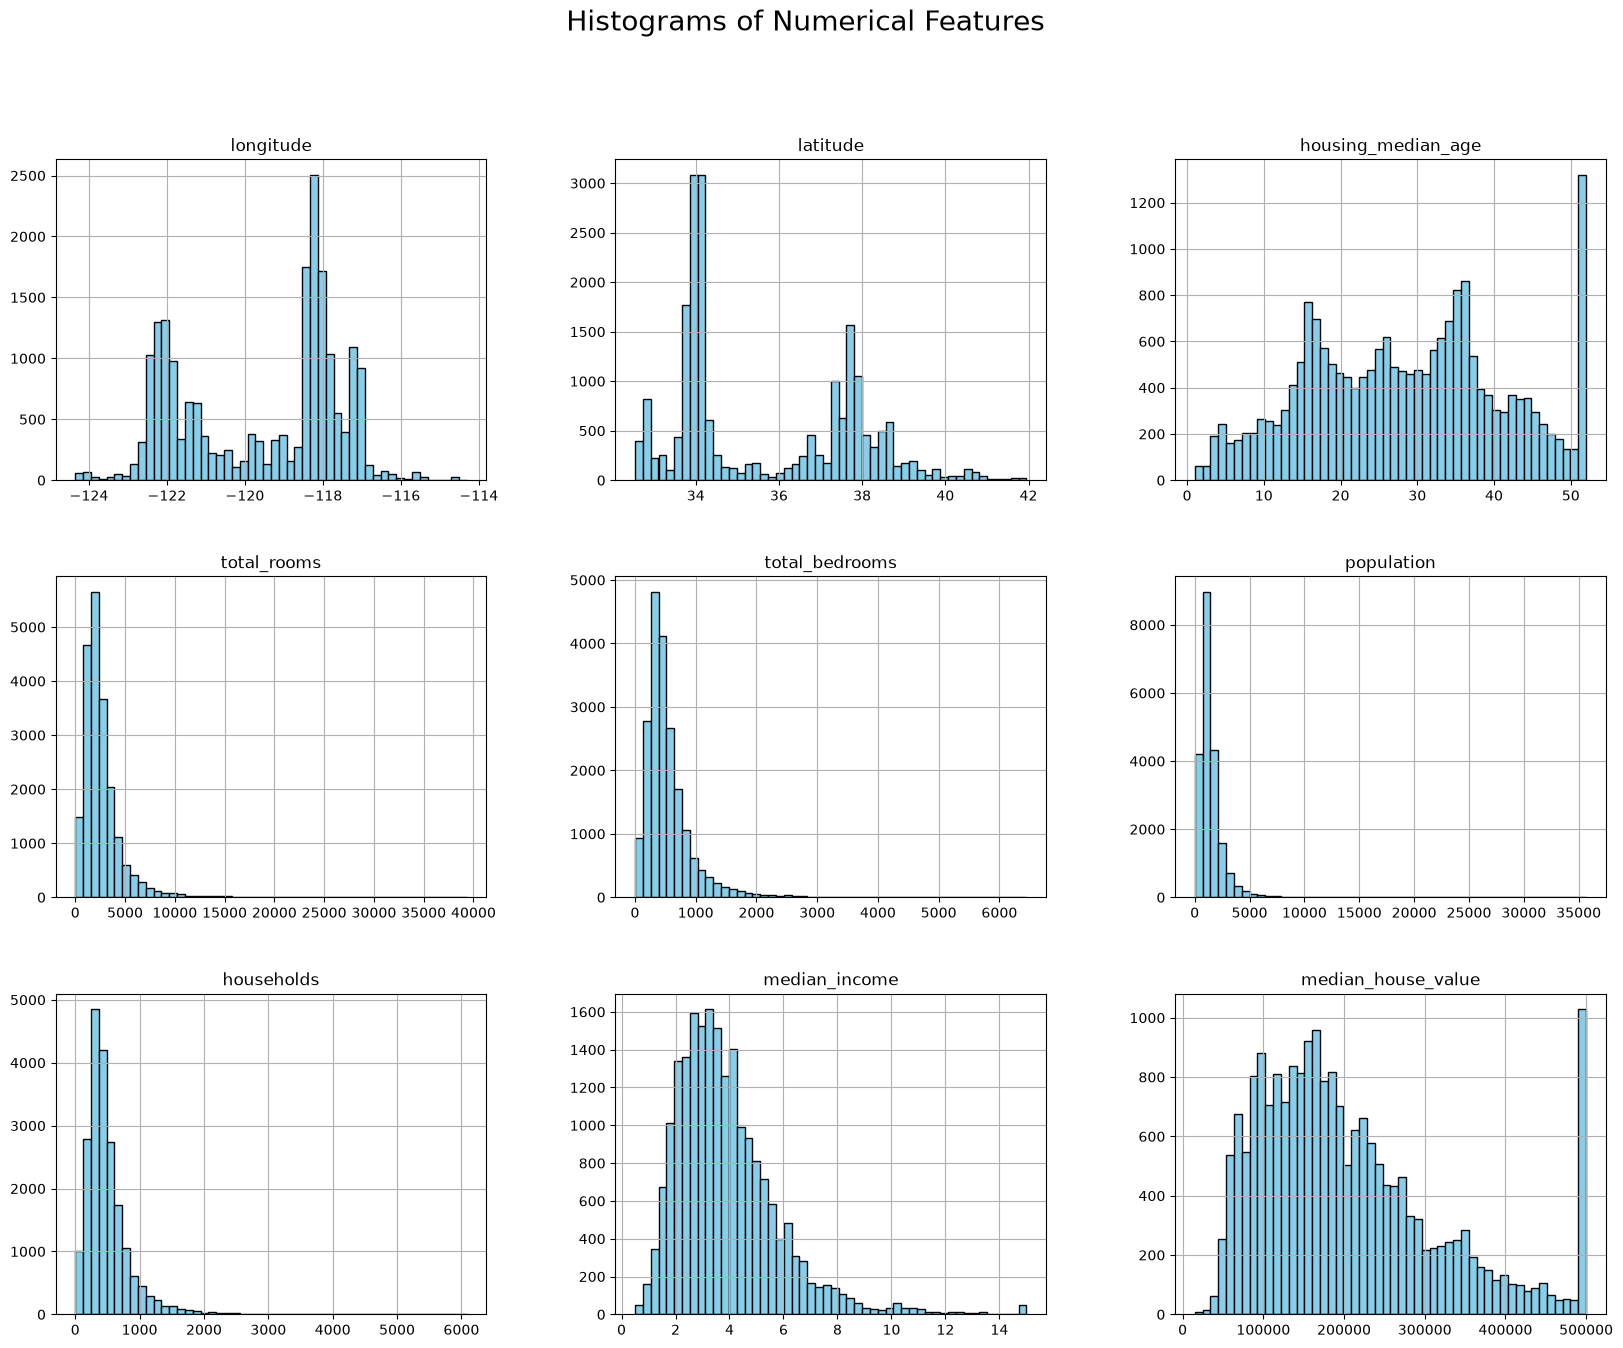

In [5]:
df.hist(bins=50, figsize=(20, 15), color='skyblue', edgecolor='black')
plt.suptitle('Histograms of Numerical Features', fontsize=20)
plt.show()

### Geographical Data Plot
Since we have latitude and longitude, we can plot the data geographically to see where expensive houses are located.

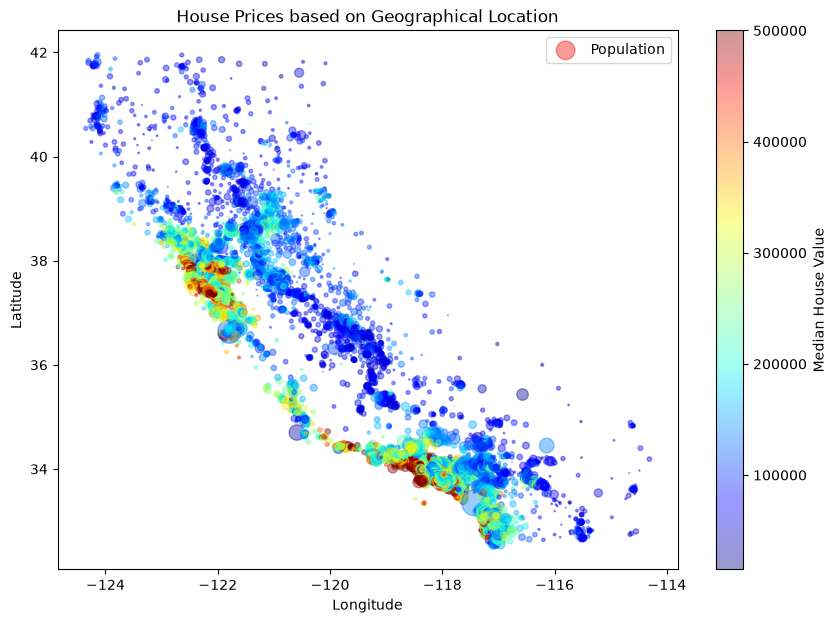

In [6]:
plt.figure(figsize=(10, 7))
sc = plt.scatter(df['longitude'], df['latitude'], alpha=0.4, 
                 s=df['population']/100, label='Population', 
                 c=df['median_house_value'], cmap=plt.get_cmap('jet'))
plt.colorbar(sc, label='Median House Value')
plt.title('House Prices based on Geographical Location')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()

### Correlation Matrix
Let's find out which features correlate the most with the `median_house_value`.

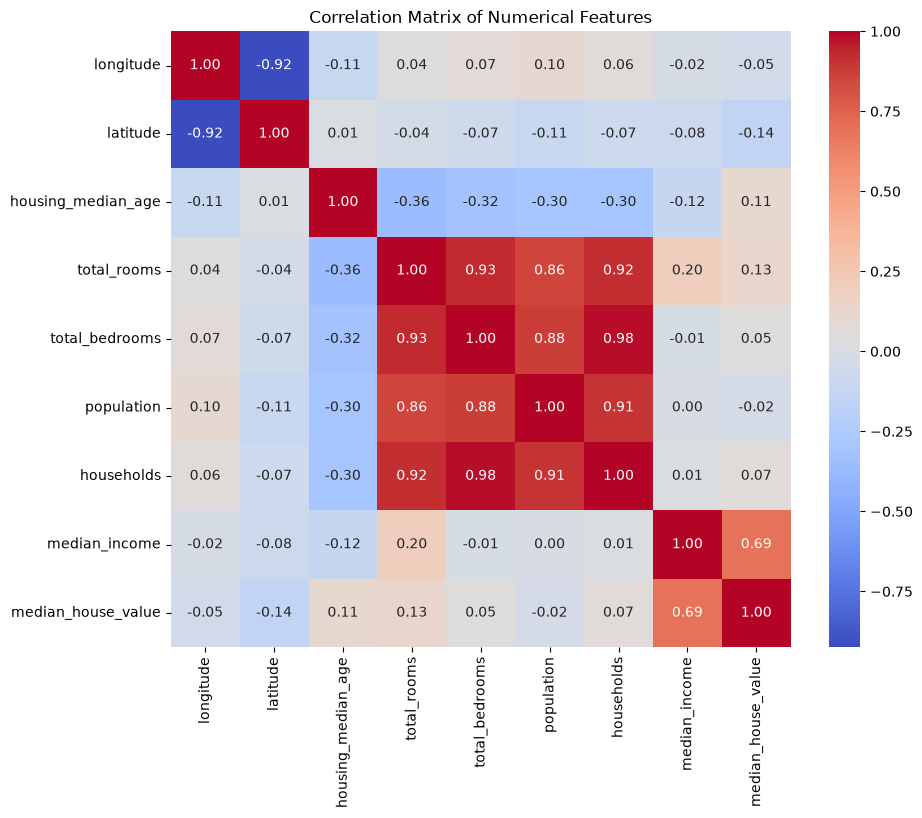

In [7]:
plt.figure(figsize=(10, 8))
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## 4. Separate Features (X) and Target (y)

In [8]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

num_cols = X.select_dtypes(include=['float64', 'int64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

print("Numerical Columns:", list(num_cols))
print("Categorical Columns:", list(cat_cols))

Numerical Columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Categorical Columns: ['ocean_proximity']


## 5. Data Preprocessing (Scaling and Encoding)

In [9]:
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

## 6. Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data size:", len(X_train))
print("Testing data size:", len(X_test))

Training data size: 16512
Testing data size: 4128


## 7. Model Evaluation and Comparison

In [11]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=50, random_state=42)
}

def evaluate_model(model, X_train, y_train, X_test, y_test):
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('model', model)])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    return mae, mse, rmse, r2

results = {}
for name, model in models.items():
    mae, mse, rmse, r2 = evaluate_model(model, X_train, y_train, X_test, y_test)
    results[name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2 Score': r2}
    
    print(f"--- {name} ---")
    print(f"MAE:  {mae:.2f}")
    print(f"MSE:  {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2:   {r2:.4f}\n")

--- Linear Regression ---
MAE:  50670.49
MSE:  4908290571.35
RMSE: 70059.19
R2:   0.6254

--- Decision Tree ---
MAE:  43604.01
MSE:  4785287042.82
RMSE: 69175.77
R2:   0.6348

--- Random Forest ---
MAE:  31930.32
MSE:  2408173803.30
RMSE: 49073.15
R2:   0.8162



## 8. Hyperparameter Tuning

In [12]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10]
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=2, n_jobs=-1, scoring='r2', verbose=1)

grid_search.fit(X_train_processed, y_train)

print("Best parameters:", grid_search.best_params_)

Fitting 2 folds for each of 4 candidates, totalling 8 fits
Best parameters: {'max_depth': None, 'n_estimators': 100}


## 9. Final Model Result

In [13]:
best_model = grid_search.best_estimator_

y_pred_final = best_model.predict(X_test_processed)

mae = mean_absolute_error(y_test, y_pred_final)
mse = mean_squared_error(y_test, y_pred_final)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_final)

print("--- Final Optimized Random Forest ---")
print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2:   {r2:.4f}")

--- Final Optimized Random Forest ---
MAE:  31628.41
MSE:  2395290032.47
RMSE: 48941.70
R2:   0.8172


## 10. Comparing Actual vs Predicted Values
Let's visualize and compare the actual house prices against our model's predictions to see how well it performed.

In [14]:
comparison_df = pd.DataFrame({'Actual Values': y_test, 'Predicted Values': y_pred_final})
comparison_df['Difference'] = abs(comparison_df['Actual Values'] - comparison_df['Predicted Values'])
comparison_df.head(10)

,Actual Values,Predicted Values,Difference
20046,47700.0,51744.00,4044.00
3024,45800.0,71115.00,25315.00
15663,500001.0,461228.37,38772.63
20484,218600.0,255273.00,36673.00
9814,278000.0,268425.00,9575.00
13311,158700.0,162987.00,4287.00
7113,198200.0,226880.02,28680.02
7668,157500.0,168563.00,11063.00
18246,340000.0,289892.05,50107.95
5723,446600.0,484745.72,38145.72


### Scatter Plot of Actual vs Predicted
A perfect model would have all points falling strictly on the red diagonal line.

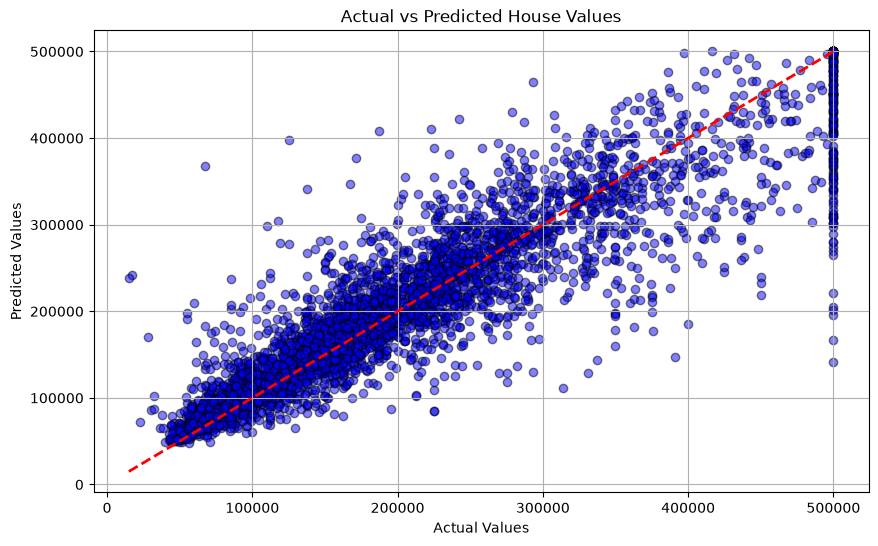

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_final, alpha=0.5, color='blue', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted House Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.show()

The data processing pipeline successfully handled the raw data, and we were able to evaluate multiple regression models to pick and optimize the best one.